# Rule of Many

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/abigailhaddad/joa/blob/main/rule_of_many.ipynb)

A federal referral method: everyone tied at a cut score goes to the selecting
official, instead of only the top three names. 659 announcements printed the phrase
in 2026. 405 of them use it.

Data is [`abigailhaddad/usajobs-scraping`](https://huggingface.co/datasets/abigailhaddad/usajobs-scraping) —
162,030 announcements, scraped page text plus the structured fields from the USAJOBS
Historical API. The query runs server-side, so only matches come down the wire.


In [1]:
# On Colab, fetch the repo so rule_of_many.py and patterns.yaml are importable.
# Locally this does nothing.
import os, sys

if "google.colab" in sys.modules:
    REPO = "/content/joa"
    !pip -q install duckdb pyyaml
    if os.path.isdir(REPO):
        !git -C {REPO} pull -q          # already cloned by an earlier run
    else:
        !git clone -q https://github.com/abigailhaddad/joa.git {REPO}
    os.chdir(REPO)
    # An earlier run may have imported an older copy; drop it so the pull takes.
    sys.modules.pop("rule_of_many", None)
    print("repo at", os.getcwd())


In [2]:
import matplotlib.pyplot as plt
import pandas as pd

import rule_of_many as rom

# Validated categorical palette (dataviz skill defaults, checked with
# validate_palette.js: CVD ΔE 24.7, normal-vision ΔE 33.6, both well clear).
APPLIED, NEGATED = "#2a78d6", "#eb6834"
INK, INK_2, GRID = "#0b0b0b", "#52514e", "#dcdcd8"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "font.size": 10, "axes.titlesize": 12,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_2,
    "xtick.color": INK_2, "ytick.color": INK_2,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.dpi": 130,
})


## Pull the mentions

One row per announcement containing the phrase, plus one row per occurrence with
±300 characters around it. About 40 seconds against HuggingFace.


In [3]:
hits, contexts = rom.fetch()
counts = rom.monthly()

print(f"{len(hits):,} announcements contain the phrase, {len(contexts):,} occurrences")


659 announcements contain the phrase, 1,003 occurrences


## Why the raw count is wrong

Look at what surrounds the phrase and two completely different sentences show up.


In [4]:
def window(ctx, w=95):
    t = " ".join(str(ctx).split())
    i = t.lower().find("rule of many")
    return t[max(0, i - w):i + w]

uses = contexts[contexts.ctx.str.contains("uses the Rule of Many", case=False)].ctx.iloc[0]
disclaims = contexts[contexts.ctx.str.contains("do not apply", case=False)].ctx.iloc[0]

print("ONE ANNOUNCEMENT:\n ", window(uses), "\n")
print("ANOTHER:\n ", window(disclaims))


ONE ANNOUNCEMENT:
  n an assessment may also result in your removal from consideration. This announcement uses the Rule of Many/Cut-off Score method under 5 CFR § 332.402. Under Rule of Many, a numerical rankin 

ANOTHER:
  civil service. Under the provisions of the Direct Hire Authority, Veterans Preference and the "Rule of Many" do not apply. Learn more about this agency Summary IT Specialist (APPSW), JAVA An


The second is a direct-hire-authority announcement listing what it's exempt from. It
prints "Rule of Many" precisely because the rule is *not* being used, and a phrase
match counts it as an adopter.

`patterns.yaml` holds the rules for telling them apart — negation phrasings, then
application phrasings, matched against each occurrence. Negation wins a tie. An
announcement counts as `applied` if any occurrence reads that way, `negated` if all
of them read as negations.


In [5]:
status = rom.classify(contexts)
df = hits.assign(status=hits.usajobsControlNumber.map(status),
                 month=hits.positionOpenDate.str[:7])

df.status.value_counts().rename("announcements").to_frame()


,announcements
status,
applied,405
negated,254


254 of 659 — 39% — name the rule to disclaim it. Nothing lands in `unclear`, and no
announcement contains both readings, so the split isn't a judgment call.


## Over the year


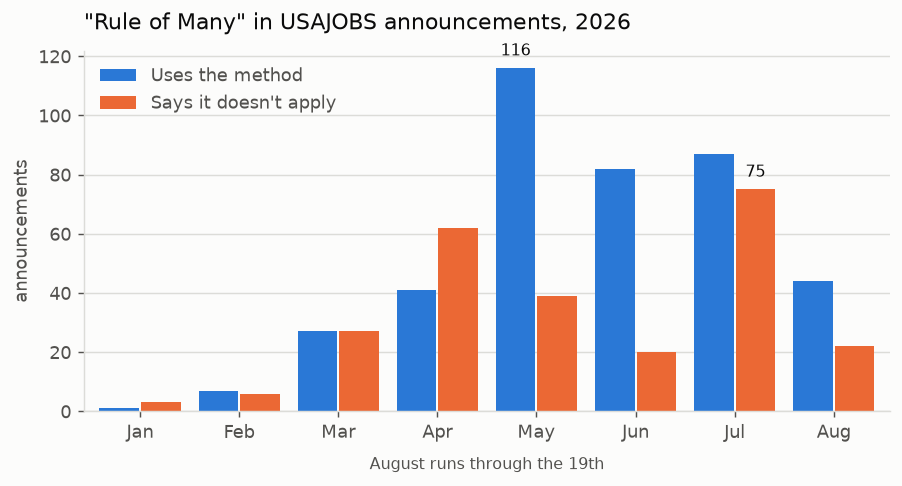

In [6]:
by_month = (df.pivot_table(index="month", columns="status", aggfunc="size", fill_value=0)
              .reindex(columns=["applied", "negated"], fill_value=0))

fig, ax = plt.subplots(figsize=(8, 3.6))
x = range(len(by_month))
w = 0.40
gap = 0.02   # 2px surface gap between adjacent bars
b1 = ax.bar([i - w/2 - gap/2 for i in x], by_month.applied, w, color=APPLIED, label="Uses the method")
b2 = ax.bar([i + w/2 + gap/2 for i in x], by_month.negated, w, color=NEGATED, label="Says it doesn't apply")

# Selective direct labels: each series' peak only, the rest read off the axis.
for bars in (b1, b2):
    peak = max(bars, key=lambda r: r.get_height())
    ax.text(peak.get_x() + peak.get_width()/2, peak.get_height() + 3,
            f"{int(peak.get_height())}", ha="center", va="bottom",
            fontsize=9, color=INK)

ax.set_xticks(list(x))
MONTHS = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
ax.set_xticklabels([MONTHS[int(m[5:]) - 1] for m in by_month.index])
ax.set_ylabel("announcements")
ax.set_title("\"Rule of Many\" in USAJOBS announcements, 2026", color=INK, loc="left", pad=12)
ax.yaxis.grid(True, color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(frameon=False, loc="upper left", labelcolor=INK_2)
ax.margins(x=0.02)
ax.set_xlabel("August runs through the 19th", fontsize=9, labelpad=8)
plt.show()


Both curves climb, and not together — April and July are mostly disclaimers, May and
June mostly real use. A raw phrase count adds them up and tracks neither.

Against every announcement posted:


In [7]:
table = counts.set_index("month")[["postings", "rule_of_many", "rule_of_three"]]
table.assign(uses_method=by_month.applied.values, says_not_applicable=by_month.negated.values)


,postings,rule_of_many,rule_of_three,uses_method,says_not_applicable
month,,,,,
2026_01,16173,4,200,1,3
2026_02,18837,13,186,7,6
2026_03,23124,54,218,27,27
2026_04,23845,103,197,41,62
2026_05,21901,155,207,116,39
2026_06,21965,102,239,82,20
2026_07,22597,162,258,87,75
2026_08,13588,66,136,44,22


"Rule of three" holds flat all year while this climbs. Nobody is swapping the label
on an existing practice.


## Who uses it


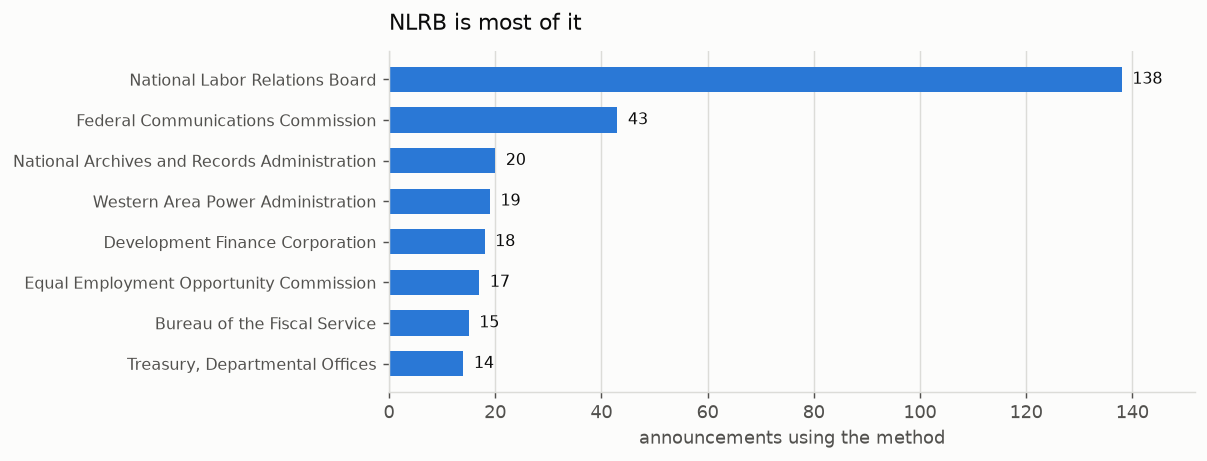

In [8]:
agencies = (df.pivot_table(index="hiringAgencyName", columns="status", aggfunc="size", fill_value=0)
              .reindex(columns=["applied", "negated"], fill_value=0)
              .sort_values("applied", ascending=False))
top = agencies.head(8).iloc[::-1]

fig, ax = plt.subplots(figsize=(8, 3.4))
bars = ax.barh(range(len(top)), top.applied, height=0.62, color=APPLIED)
for i, v in enumerate(top.applied):
    ax.text(v + 2, i, str(v), va="center", fontsize=9, color=INK)

ax.set_yticks(range(len(top)))
ax.set_yticklabels(top.index, fontsize=9)
ax.set_xlabel("announcements using the method")
ax.set_title("NLRB is most of it", color=INK, loc="left", pad=12)
ax.xaxis.grid(True, color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.margins(x=0.10)
plt.show()


## Agencies that only ever disclaim it

Read these as adopters off a phrase match and you would be wrong about every one.


In [9]:
agencies[(agencies.applied == 0) & (agencies.negated >= 10)].sort_values("negated", ascending=False)


status,applied,negated
hiringAgencyName,,
Social Security Administration,0,79
Federal Highway Administration,0,60
National Gallery of Art,0,38
Federal Transit Administration,0,28


SSA is the one to watch. It has the second-highest raw mention count in the corpus
and uses the method zero times.


## Why this needs a scraper

Everything above reads scraped announcement pages. The obvious alternative is the
USAJOBS API's own text field, `MatchedObjectDescriptor`, which the
[usajobs_historical](https://github.com/abigailhaddad/usajobs_historical) mirror
already collects. It gives a different answer.


In [10]:
import os

API = "cache/current_jobs_2026.parquet"   # ~340MB, see PIPELINE.md

if os.path.exists(API):
    import duckdb
    con = duckdb.connect()
    con.execute("SET memory_limit='6GB'; SET enable_progress_bar=false;")
    api = con.execute(
        "SELECT count(*) AS postings_with_api_text, "
        "count(*) FILTER (regexp_matches(CAST(MatchedObjectDescriptor AS VARCHAR), "
        f"'(?i){rom.PHRASE}')) AS mentions_found "
        f"FROM read_parquet('{API}') WHERE substr(positionOpenDate, 1, 4) = '2026'"
    ).df()
else:
    print("cache/current_jobs_2026.parquet not present, showing recorded numbers")
    api = pd.DataFrame([{"postings_with_api_text": 156756, "mentions_found": 502}])

print(f"scraped pages: {len(hits)} mentions")
print(f"API text:      {int(api.mentions_found.iloc[0])} mentions")
api


scraped pages: 659 mentions
API text:      502 mentions


,postings_with_api_text,mentions_found
0,156766,502


The API misses 157 of the 659, a 31% undercount, for two separate reasons.

It never saw some postings. The Search API only lists jobs open right now, so
anything that opens and closes between collection runs is invisible. The Historical
API does report closed postings, so the gap is measurable: 5,274 of 2026's 162,030
announcements, about 3%, and it isn't spread evenly. OPM had API text for 159 of its
724 postings.

And for postings it did see, the text is incomplete. `MatchedObjectDescriptor` drops
content the announcement page shows.

The second problem is the bigger one here. Federal Highway has 60 announcements naming
the rule, all of them disclaimers, and the API finds zero. The postings aren't missing —
the API holds all 60, with the phrase absent from the text of every one. Federal Transit
is the same, 28 and zero. Read the API and neither agency appears to have encountered
the rule at all.

Neither gap can be backfilled: the Historical API returns metadata only, Search returns
open jobs only. usajobs.gov serves closed announcements indefinitely, so the page is
the source.


## Read the announcements


In [11]:
applied = df[df.status == "applied"]
applied[["positionOpenDate", "hiringAgencyName", "occupationalSeries", "link"]].head(10)


,positionOpenDate,hiringAgencyName,occupationalSeries,link
0,2026-01-23,"Offices, Boards and Divisions",0950,https://www.usajobs.gov/job/855359900
10,2026-02-12,Bureau of Prisons/Federal Prison System,0060,https://www.usajobs.gov/job/858058400
11,2026-02-12,Federal Communications Commission,0301,https://www.usajobs.gov/job/857515500
12,2026-02-12,Federal Communications Commission,0201,https://www.usajobs.gov/job/857523200
13,2026-02-12,Federal Communications Commission,0510,https://www.usajobs.gov/job/857581400
14,2026-02-13,Federal Communications Commission,0855,https://www.usajobs.gov/job/857694500
15,2026-02-17,Federal Communications Commission,0855,https://www.usajobs.gov/job/857713800
16,2026-02-25,Bureau of Prisons/Federal Prison System,0060,https://www.usajobs.gov/job/858904800
17,2026-03-03,U.S. Census Bureau,1530,https://www.usajobs.gov/job/859611200
18,2026-03-04,Federal Communications Commission,0560,https://www.usajobs.gov/job/859903500


In [12]:
df.to_csv("results/rule_of_many.csv", index=False)
print(f"wrote results/rule_of_many.csv, {len(df):,} rows")


wrote results/rule_of_many.csv, 659 rows
